# Florence-2 FP32 vs BF16 — Analysis Notebook

이 노트북은 두 개의 소스 observation(`../2026-04-20-florence2-base-fp32`, `../2026-04-20-florence2-base-bf16`)을 로드해 시각화·정량비교한다.

**주의**: outputs를 지우지 말고 커밋한다. 포트폴리오 자산.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

HERE = Path.cwd()
FP32_DIR = HERE.parent / "2026-04-20-florence2-base-fp32"
BF16_DIR = HERE.parent / "2026-04-20-florence2-base-bf16"

fp = json.loads((FP32_DIR / "summary.json").read_text(encoding="utf-8"))
bf = json.loads((BF16_DIR / "summary.json").read_text(encoding="utf-8"))
compare = json.loads((HERE / "summary.json").read_text(encoding="utf-8"))

print("FP32 points:", len(fp['observation_points']))
print("BF16 points:", len(bf['observation_points']))
print("GPU:", fp['gpu']['name'])

FP32 points: 41
BF16 points: 41
GPU: NVIDIA GeForce RTX 4090


## 1. VRAM 사용량 비교

모델 로드 직후 / generate 중 peak. BF16가 이론치대로 절반이어야 한다(parameter = 2 bytes).

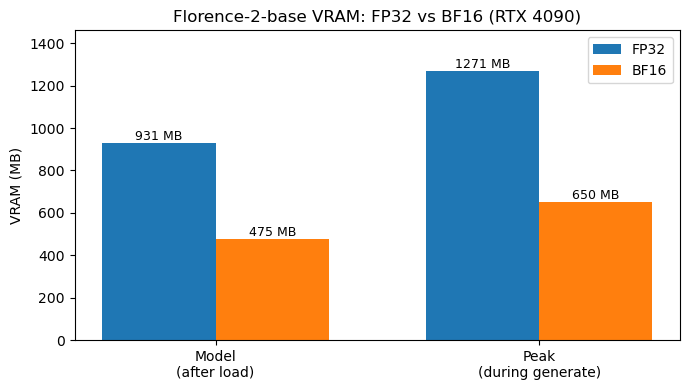


Ratio BF16 / FP32:
  model:  0.510
  peak:   0.512


In [2]:
fp_pf = fp['florence_profile']
bf_pf = bf['florence_profile']

labels = ['Model\n(after load)', 'Peak\n(during generate)']
fp_mb = [fp_pf['model_vram_bytes_after_load']/1e6, fp_pf['peak_vram_bytes_during_generate']/1e6]
bf_mb = [bf_pf['model_vram_bytes_after_load']/1e6, bf_pf['peak_vram_bytes_during_generate']/1e6]

x = np.arange(len(labels))
w = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(x - w/2, fp_mb, w, label='FP32', color='#1f77b4')
b2 = ax.bar(x + w/2, bf_mb, w, label='BF16', color='#ff7f0e')
ax.set_ylabel('VRAM (MB)')
ax.set_title('Florence-2-base VRAM: FP32 vs BF16 (RTX 4090)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
for b in b1 + b2:
    ax.annotate(f'{b.get_height():.0f} MB', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, max(fp_mb)*1.15)
plt.tight_layout()
plt.savefig('assets/vram-comparison.png', dpi=120)
plt.show()

print(f"\nRatio BF16 / FP32:")
print(f"  model:  {bf_mb[0]/fp_mb[0]:.3f}")
print(f"  peak:   {bf_mb[1]/fp_mb[1]:.3f}")

## 2. 추론 시간 (wall-clock)

warmup 1회 후 3회 측정한 값.

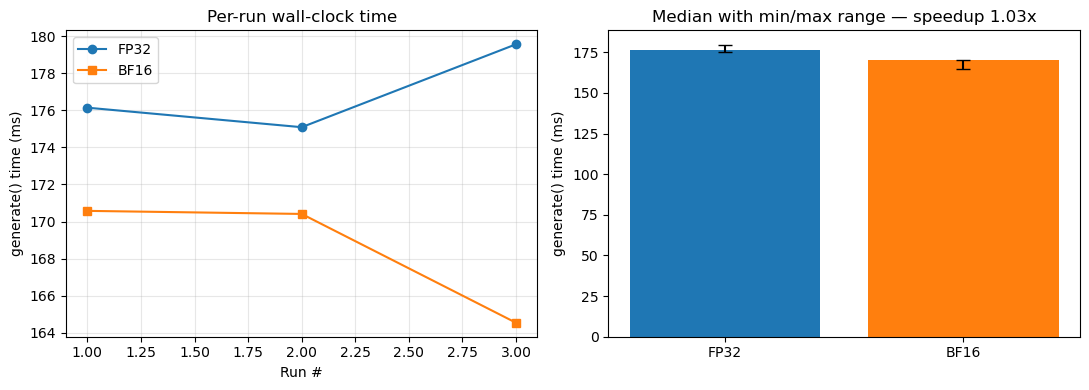

In [3]:
fp_runs = fp_pf['generate_ms_runs']
bf_runs = bf_pf['generate_ms_runs']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(range(1, len(fp_runs)+1), fp_runs, 'o-', label='FP32', color='#1f77b4')
ax1.plot(range(1, len(bf_runs)+1), bf_runs, 's-', label='BF16', color='#ff7f0e')
ax1.set_xlabel('Run #')
ax1.set_ylabel('generate() time (ms)')
ax1.set_title('Per-run wall-clock time')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.bar(['FP32', 'BF16'], [fp_pf['generate_ms_median'], bf_pf['generate_ms_median']],
        yerr=[[fp_pf['generate_ms_median']-fp_pf['generate_ms_min'], bf_pf['generate_ms_median']-bf_pf['generate_ms_min']],
              [fp_pf['generate_ms_max']-fp_pf['generate_ms_median'], bf_pf['generate_ms_max']-bf_pf['generate_ms_median']]],
        capsize=5, color=['#1f77b4', '#ff7f0e'])
ax2.set_ylabel('generate() time (ms)')
ax2.set_title(f'Median with min/max range — speedup {fp_pf["generate_ms_median"]/bf_pf["generate_ms_median"]:.2f}x')

plt.tight_layout()
plt.savefig('assets/timing-comparison.png', dpi=120)
plt.show()

## 3. Bounding box drift

각 박스별로 FP32 vs BF16 좌표 차이. 가설: mantissa 7bit 정밀도 손실이 `<loc_N>` 토큰 → 원본 픽셀 스케일업에서 나타난다.

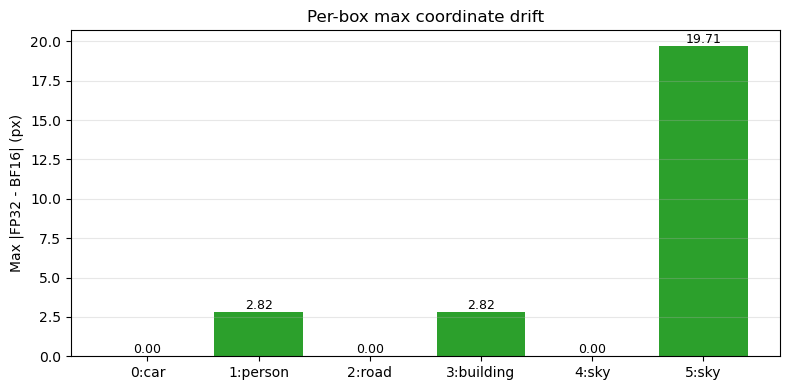

Max drift across all boxes: 19.71 px
Image size: {'width': 1584, 'height': 2816}
Max drift as fraction of height: 0.700%


In [4]:
fp_boxes = np.array(fp['florence_result']['boxes'])
bf_boxes = np.array(bf['florence_result']['boxes'])
labels = fp['florence_result']['labels']

assert fp['florence_result']['labels'] == bf['florence_result']['labels'], 'label mismatch'

diffs = np.abs(fp_boxes - bf_boxes)
per_box_max = diffs.max(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([f'{i}:{l}' for i, l in enumerate(labels)], per_box_max, color='#2ca02c')
ax.set_ylabel('Max |FP32 - BF16| (px)')
ax.set_title('Per-box max coordinate drift')
for b, v in zip(bars, per_box_max):
    ax.annotate(f'{v:.2f}', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('assets/bbox-drift.png', dpi=120)
plt.show()

print(f'Max drift across all boxes: {per_box_max.max():.2f} px')
print(f'Image size: {fp["florence_result"]["image_size"]}')
image_height = fp['florence_result']['image_size']['height']
print(f'Max drift as fraction of height: {per_box_max.max()/image_height*100:.3f}%')

## 4. Bbox overlay 비교

원본 이미지 위에 FP32 박스(파랑)와 BF16 박스(주황)를 겹쳐서 시각적으로 드리프트 확인.

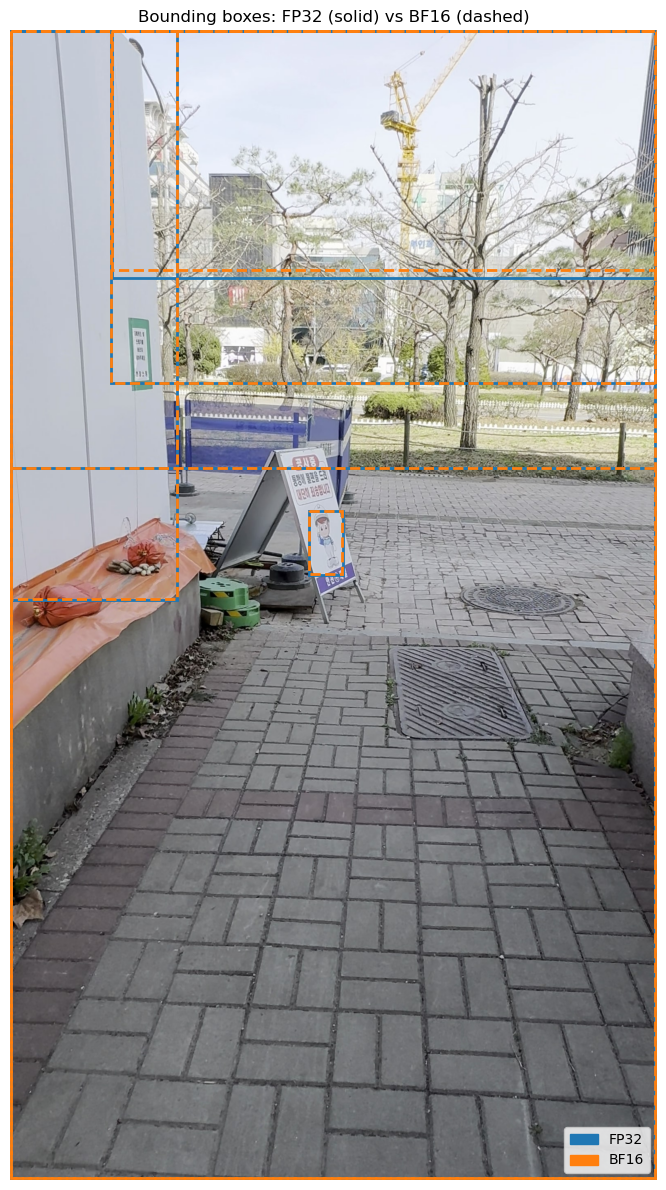

In [5]:
from PIL import Image
import matplotlib.patches as mpatches

img_path = Path('../../../..') / fp['inputs'][0]['path'].replace('\\', '/')
img = Image.open(img_path).convert('RGB')

fig, ax = plt.subplots(figsize=(8, 12))
ax.imshow(img)

for box, label in zip(fp_boxes, labels):
    x1,y1,x2,y2 = box
    r = mpatches.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, edgecolor='#1f77b4', linewidth=2, linestyle='-')
    ax.add_patch(r)
for box, label in zip(bf_boxes, labels):
    x1,y1,x2,y2 = box
    r = mpatches.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, edgecolor='#ff7f0e', linewidth=2, linestyle='--')
    ax.add_patch(r)

ax.legend(handles=[mpatches.Patch(color='#1f77b4', label='FP32'),
                   mpatches.Patch(color='#ff7f0e', label='BF16')], loc='lower right')
ax.set_title('Bounding boxes: FP32 (solid) vs BF16 (dashed)')
ax.axis('off')
plt.tight_layout()
plt.savefig('assets/bbox-overlay.png', dpi=120)
plt.show()

## 5. pixel_values 분포

입력 텐서 자체의 분포를 시각화. 두 실행에서 입력은 동일하되 BF16 실행은 모델에 입력되기 직전 cast된다. 분포 자체는 같아야 한다.

FP32 pixel_values: torch.Size([1, 3, 768, 768]) torch.float32
BF16 pixel_values: torch.Size([1, 3, 768, 768]) torch.bfloat16


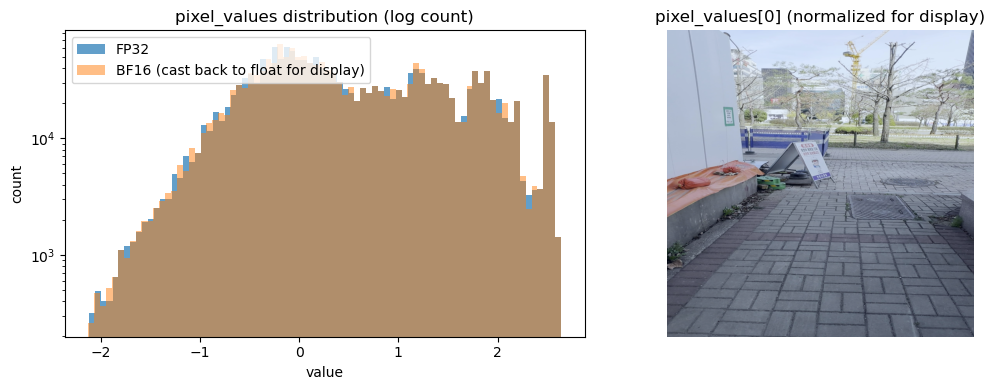

In [6]:
import torch

fp_pv = torch.load(FP32_DIR / 'outputs' / 'raw' / 'florence-2__processor__inputs.pixel_values.pt', weights_only=True)
bf_pv = torch.load(BF16_DIR / 'outputs' / 'raw' / 'florence-2__processor__inputs.pixel_values.pt', weights_only=True)
print('FP32 pixel_values:', fp_pv.shape, fp_pv.dtype)
print('BF16 pixel_values:', bf_pv.shape, bf_pv.dtype)

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].hist(fp_pv.float().flatten().cpu().numpy(), bins=80, color='#1f77b4', alpha=0.7, label='FP32')
axs[0].hist(bf_pv.float().flatten().cpu().numpy(), bins=80, color='#ff7f0e', alpha=0.5, label='BF16 (cast back to float for display)')
axs[0].set_xlabel('value')
axs[0].set_ylabel('count')
axs[0].set_title('pixel_values distribution (log count)')
axs[0].set_yscale('log')
axs[0].legend()

# show image tensor
disp = fp_pv[0].permute(1,2,0).float().cpu().numpy()
disp = (disp - disp.min())/(disp.max()-disp.min())
axs[1].imshow(disp)
axs[1].set_title('pixel_values[0] (normalized for display)')
axs[1].axis('off')
plt.tight_layout()
plt.savefig('assets/pixel-values.png', dpi=120)
plt.show()

## 6. (follow-up) output_ids 토큰 시퀀스 비교

Q2 가설: output_ids가 bit-exact로 동일하면 drift는 post_process에서만 발생. 다르면 decode 중 argmax 경계 근처에서 다른 토큰이 선택된 것.

In [7]:
fp_oids = torch.load(FP32_DIR / 'outputs' / 'raw' / 'florence-2__decoder__generate.output_ids.pt', weights_only=True)
bf_oids = torch.load(BF16_DIR / 'outputs' / 'raw' / 'florence-2__decoder__generate.output_ids.pt', weights_only=True)

print('FP32 output_ids:', fp_oids.shape, fp_oids.dtype)
print('BF16 output_ids:', bf_oids.shape, bf_oids.dtype)
print('Identical:', torch.equal(fp_oids, bf_oids))

if not torch.equal(fp_oids, bf_oids):
    diff_positions = (fp_oids != bf_oids).nonzero(as_tuple=False)
    print(f'Differing positions: {diff_positions.tolist()}')
    print(f'FP32 tokens: {fp_oids.flatten().tolist()}')
    print(f'BF16 tokens: {bf_oids.flatten().tolist()}')

FP32 output_ids: torch.Size([1, 38]) torch.int64
BF16 output_ids: torch.Size([1, 38]) torch.int64
Identical: False
Differing positions: [[0, 16], [0, 17], [0, 27], [0, 36]]
FP32 tokens: [2, 0, 250, 1345, 50269, 50269, 51267, 51267, 5901, 50269, 50269, 51266, 51267, 5970, 50730, 50686, 50783, 50742, 14288, 50269, 50649, 51267, 51267, 11557, 50269, 50269, 50526, 50764, 18708, 50425, 50269, 51267, 50575, 50426, 50269, 51267, 50484, 2]
BF16 tokens: [2, 0, 250, 1345, 50269, 50269, 51267, 51267, 5901, 50269, 50269, 51266, 51267, 5970, 50730, 50686, 50782, 50741, 14288, 50269, 50649, 51267, 51267, 11557, 50269, 50269, 50526, 50763, 18708, 50425, 50269, 51267, 50575, 50426, 50269, 51267, 50477, 2]
